# Round 3 — Velvetfruit Vouchers (options)

Replicates the Frankfurt Hedgehogs (Prosperity 3 winners) Round 3 research workflow on Prosperity 4 data.

**Underlying:** `VELVETFRUIT_EXTRACT` (~5250)  
**Vouchers (calls):** `VEV_4000, VEV_4500, VEV_5000, VEV_5100, VEV_5200, VEV_5300, VEV_5400, VEV_5500, VEV_6000, VEV_6500`  
**Independent product:** `HYDROGEL_PACK` (delta-1, brief look at the end)

**TTE schedule** (matches Frankfurt's `tte = (8 - day - ts/1e6)/365`):
- Historical day 0 → 8d → 7d
- Historical day 1 → 7d → 6d
- Historical day 2 → 6d → 5d
- Live R3 starts at 5d

**Risk-free rate r = 0** (no funding/lending in Prosperity)

**Pipeline:** load → wall_mid → BS+IV → vol smile fit → IV deviations → price deviations → autocorr → strike viability → sizing thresholds.

In [6]:
import math
from pathlib import Path
from statistics import NormalDist

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True

DATA_DIR = Path('../data/ROUND3')

UNDERLYING = 'VELVETFRUIT_EXTRACT'
INDEPENDENT = 'HYDROGEL_PACK'
VOUCHERS = ['VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200',
            'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']
STRIKES = {v: int(v.split('_')[-1]) for v in VOUCHERS}

POS_LIMITS = {UNDERLYING: 200, INDEPENDENT: 200, **{v: 300 for v in VOUCHERS}}

DAYS_PER_YEAR = 365
TTE_AT_DAY0_START = 8  # days, matches Frankfurt convention

_N = NormalDist()

## 1. Load data

Concat all 3 historical days. Build a global `t` axis for plotting (`day * 1_000_000 + timestamp`).

In [7]:
def load_prices():
    frames = []
    for d in range(3):
        df = pd.read_csv(DATA_DIR / f'prices_round_3_day_{d}.csv', sep=';')
        df['day'] = d
        frames.append(df)
    out = pd.concat(frames, ignore_index=True)
    out['t'] = out['day'] * 1_000_000 + out['timestamp']
    return out

def load_trades():
    frames = []
    for d in range(3):
        df = pd.read_csv(DATA_DIR / f'trades_round_3_day_{d}.csv', sep=';')
        df['day'] = d
        frames.append(df)
    out = pd.concat(frames, ignore_index=True)
    out['t'] = out['day'] * 1_000_000 + out['timestamp']
    return out

prices = load_prices()
trades = load_trades()

print('prices:', prices.shape, ' trades:', trades.shape)
print('products:', sorted(prices['product'].unique()))
prices.head(3)

prices: (360000, 18)  trades: (4048, 9)
products: ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,t
0,0,0,VEV_5400,22,25,NaN,NaN,NaN,NaN,24,25,NaN,NaN,NaN,NaN,23.0,0.0,0
1,0,0,VEV_6500,0,16,NaN,NaN,NaN,NaN,1,16,NaN,NaN,NaN,NaN,0.5,0.0,0
2,0,0,VEV_5500,8,25,NaN,NaN,NaN,NaN,9,25,NaN,NaN,NaN,NaN,8.5,0.0,0


In [8]:
rows = []
for prod, g in prices.groupby('product'):
    bv = g[['bid_volume_1','bid_volume_2','bid_volume_3']].fillna(0).sum(axis=1)
    av = g[['ask_volume_1','ask_volume_2','ask_volume_3']].fillna(0).sum(axis=1)
    rows.append({
        'product': prod,
        'rows': len(g),
        'mid_min': g['mid_price'].min(),
        'mid_max': g['mid_price'].max(),
        'mid_unique': g['mid_price'].nunique(),
        'avg_bid_vol': bv.mean(),
        'avg_ask_vol': av.mean(),
    })
summary = pd.DataFrame(rows).sort_values('product').reset_index(drop=True)
summary

,product,rows,mid_min,mid_max,mid_unique,avg_bid_vol,avg_ask_vol
0,HYDROGEL_PACK,30000,9891.0,10079.0,368,37.627733,37.635933
1,VELVETFRUIT_EXTRACT,30000,5198.0,5300.0,199,60.365167,60.367100
2,VEV_4000,30000,1198.0,1300.0,196,33.515367,33.518067
3,VEV_4500,30000,698.5,799.5,190,27.011267,27.013967
4,VEV_5000,30000,206.5,300.5,178,27.011267,27.013967
5,VEV_5100,30000,125.0,205.5,156,27.011267,27.013967
6,VEV_5200,30000,64.0,122.5,118,27.009200,27.011900
7,VEV_5300,30000,26.5,65.5,79,22.495600,22.498300
8,VEV_5400,30000,6.5,27.0,42,22.483333,22.486033
9,VEV_5500,30000,2.5,12.5,21,22.478333,22.481033


Already visible: **VEV_6000** and **VEV_6500** have only a few unique mids each — essentially dead books. Their IVs will be uninformative; we'll exclude them from smile fitting and scalping.

## 2. Sanity plots — mid series

Underlying, the independent delta-1 product, and every voucher on a shared x-axis.

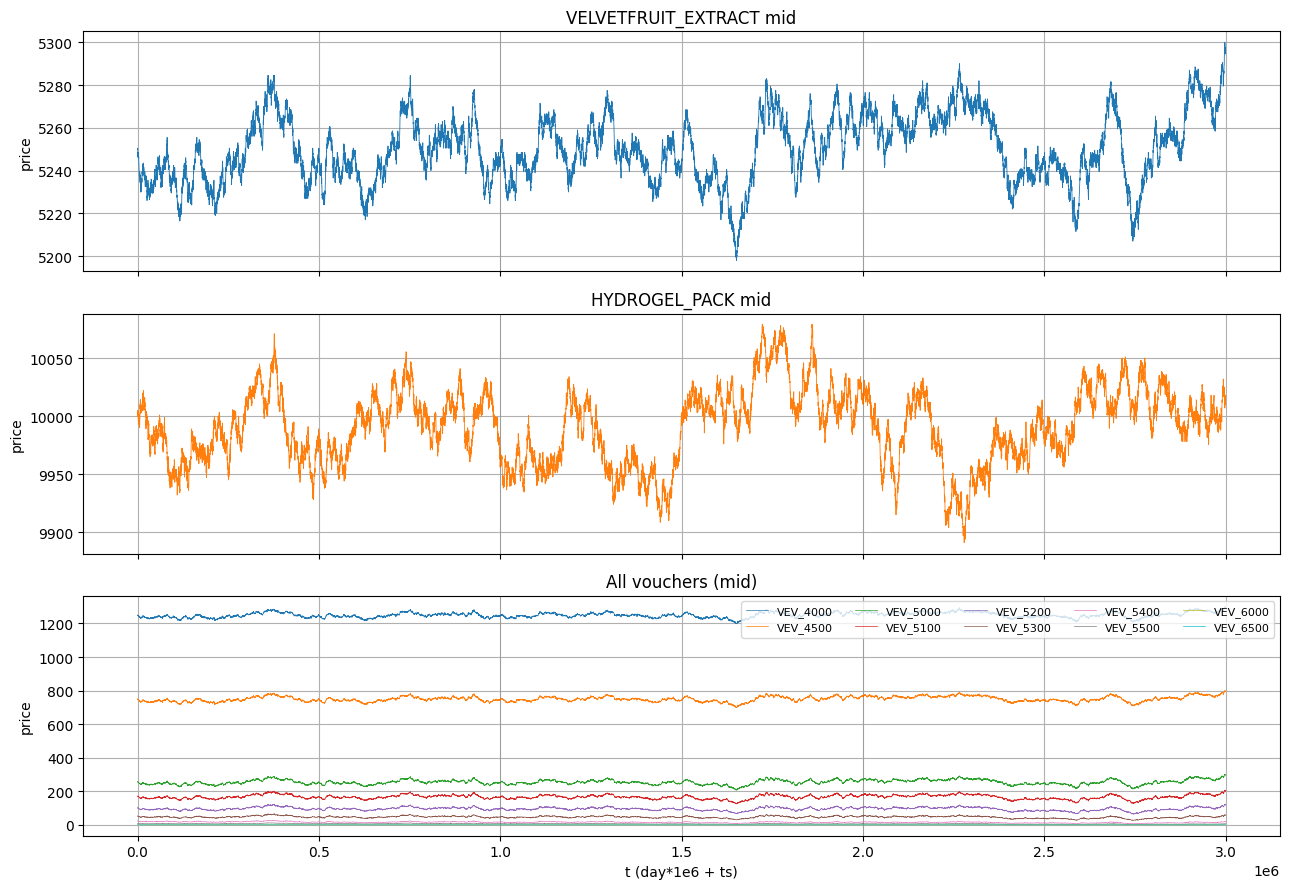

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

u = prices[prices['product'] == UNDERLYING].sort_values('t')
axes[0].plot(u['t'], u['mid_price'], lw=0.6)
axes[0].set_title(f'{UNDERLYING} mid'); axes[0].set_ylabel('price')

h = prices[prices['product'] == INDEPENDENT].sort_values('t')
axes[1].plot(h['t'], h['mid_price'], lw=0.6, color='tab:orange')
axes[1].set_title(f'{INDEPENDENT} mid'); axes[1].set_ylabel('price')

for v in VOUCHERS:
    g = prices[prices['product'] == v].sort_values('t')
    axes[2].plot(g['t'], g['mid_price'], lw=0.5, label=v)
axes[2].set_title('All vouchers (mid)'); axes[2].set_ylabel('price'); axes[2].set_xlabel('t (day*1e6 + ts)')
axes[2].legend(ncol=5, fontsize=8, loc='upper right')
for d in [1_000_000, 2_000_000]:
    for ax in axes:
        ax.axvline(d, color='k', alpha=0.15, lw=0.5)
plt.tight_layout(); plt.show()

## 3. Wall mid

Frankfurt's live trader uses the midpoint of the **largest-volume** bid level and the largest-volume ask level ("wall mid"), not top-of-book mid. Much less noisy from quote flicker.

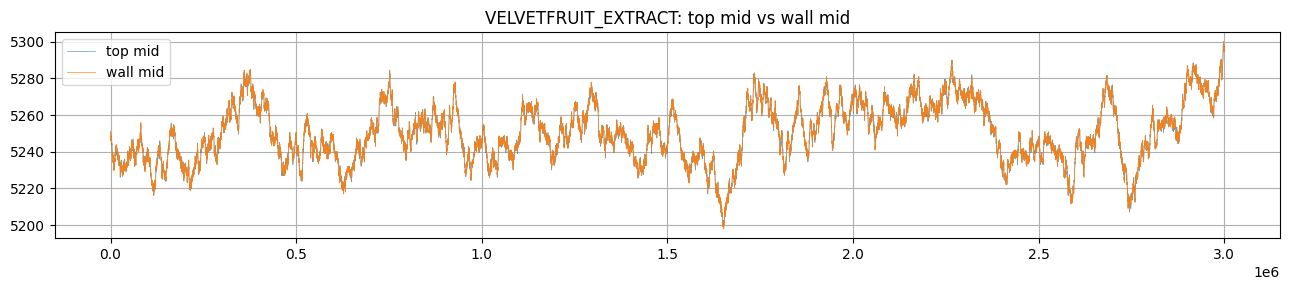

count    30000.000000
mean        -0.019267
std          0.534514
min         -2.000000
25%         -0.500000
50%          0.000000
75%          0.500000
max          1.500000
dtype: float64

In [5]:
def add_wall_mid(df):
    bid_p = df[['bid_price_1','bid_price_2','bid_price_3']].to_numpy(dtype=float)
    bid_v = df[['bid_volume_1','bid_volume_2','bid_volume_3']].to_numpy(dtype=float)
    ask_p = df[['ask_price_1','ask_price_2','ask_price_3']].to_numpy(dtype=float)
    ask_v = df[['ask_volume_1','ask_volume_2','ask_volume_3']].to_numpy(dtype=float)

    bid_v = np.nan_to_num(bid_v, nan=0.0)
    ask_v = np.nan_to_num(ask_v, nan=0.0)

    bid_idx = np.argmax(bid_v, axis=1)
    ask_idx = np.argmax(ask_v, axis=1)
    rows = np.arange(len(df))

    bid_wall = bid_p[rows, bid_idx]
    ask_wall = ask_p[rows, ask_idx]

    bid_wall = np.where(bid_v.sum(axis=1) == 0, bid_p[:, 0], bid_wall)
    ask_wall = np.where(ask_v.sum(axis=1) == 0, ask_p[:, 0], ask_wall)

    df = df.copy()
    df['bid_wall'] = bid_wall
    df['ask_wall'] = ask_wall
    df['wall_mid'] = (bid_wall + ask_wall) / 2.0
    return df

prices = add_wall_mid(prices)

u = prices[prices['product'] == UNDERLYING].sort_values('t')
fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(u['t'], u['mid_price'], label='top mid', lw=0.5, alpha=0.7)
ax.plot(u['t'], u['wall_mid'], label='wall mid', lw=0.5, alpha=0.9)
ax.set_title(f'{UNDERLYING}: top mid vs wall mid'); ax.legend()
plt.tight_layout(); plt.show()

(u['mid_price'] - u['wall_mid']).describe()

## 4. Black-Scholes infrastructure (r=0)

`bs_call`, `bs_vega`, and `bs_iv` via `scipy.optimize.brentq`.

In [6]:
def bs_call(S, K, T, sigma, r=0.0):
    if T <= 0 or sigma <= 0:
        return max(S - K, 0.0), (1.0 if S > K else 0.0)
    d1 = (math.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*math.sqrt(T))
    d2 = d1 - sigma*math.sqrt(T)
    price = S*_N.cdf(d1) - K*math.exp(-r*T)*_N.cdf(d2)
    return price, _N.cdf(d1)

def bs_vega(S, K, T, sigma, r=0.0):
    if T <= 0 or sigma <= 0:
        return 0.0
    d1 = (math.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*math.sqrt(T))
    return S * _N.pdf(d1) * math.sqrt(T)

def bs_iv(price, S, K, T, r=0.0, lo=1e-4, hi=5.0):
    intrinsic = max(S - K, 0.0)
    if price <= intrinsic + 1e-8:
        return float('nan')
    f = lambda s: bs_call(S, K, T, s, r)[0] - price
    try:
        if f(lo) * f(hi) > 0:
            return float('nan')
        return brentq(f, lo, hi, xtol=1e-6, maxiter=200)
    except (ValueError, RuntimeError):
        return float('nan')

p, d = bs_call(100, 100, 1.0, 0.2)
print(f'BS call sanity: price={p:.4f} (expect ~7.9656), delta={d:.4f} (~0.5398)')
print(f'IV roundtrip:   sigma_back={bs_iv(p, 100, 100, 1.0):.6f} (expect 0.2)')

BS call sanity: price=7.9656 (expect ~7.9656), delta=0.5398 (~0.5398)
IV roundtrip:   sigma_back=0.200000 (expect 0.2)


## 5. TTE per row

`TTE = (8 - day - ts/1_000_000) / 365`  (years)

In [7]:
def tte_years(day, ts):
    return (TTE_AT_DAY0_START - day - ts / 1_000_000) / DAYS_PER_YEAR

prices['tte'] = tte_years(prices['day'].to_numpy(), prices['timestamp'].to_numpy())

print('TTE day 0 ts 0     :', tte_years(0, 0)*365, 'days')
print('TTE day 0 ts 999900:', tte_years(0, 999900)*365, 'days')
print('TTE day 2 ts 999900:', tte_years(2, 999900)*365, 'days')
prices[['day','timestamp','tte']].drop_duplicates().head()

TTE day 0 ts 0     : 8.0 days
TTE day 0 ts 999900: 7.000099999999999 days
TTE day 2 ts 999900: 5.0001 days


,day,timestamp,tte
0,0,0,0.021918
12,0,100,0.021918
24,0,200,0.021917
36,0,300,0.021917
48,0,400,0.021917


## 6. Joint panel

One row per `t` with underlying wall_mid + every voucher's wall_mid as columns.

In [8]:
wide = prices.pivot_table(index=['day','timestamp','t','tte'], columns='product', values='wall_mid').reset_index()
wide.columns.name = None
wide = wide.sort_values('t').reset_index(drop=True)
print('wide shape:', wide.shape)
wide.head(3)

wide shape: (30000, 16)


,day,timestamp,t,tte,HYDROGEL_PACK,VELVETFRUIT_EXTRACT,VEV_4000,VEV_4500,VEV_5000,VEV_5100,VEV_5200,VEV_5300,VEV_5400,VEV_5500,VEV_6000,VEV_6500
0,0,0,0,0.021918,10000.0,5250.0,1250.0,750.0,257.5,171.5,102.0,52.5,23.0,8.5,0.5,0.5
1,0,100,100,0.021918,10000.5,5251.0,1251.0,751.0,258.0,172.5,102.5,53.0,23.5,8.5,0.5,0.5
2,0,200,200,0.021917,10002.5,5250.0,1250.0,750.0,257.5,171.5,102.0,52.5,23.0,8.5,0.5,0.5


## 7. Implied vol per voucher per timestamp

Solve BS IV using each voucher's wall_mid and the underlying's wall_mid as S. Drops rows where extrinsic value is below floor (unstable IV).

In [9]:
EXTRINSIC_FLOOR = 1.5

iv_cols = []
S = wide[UNDERLYING].to_numpy(dtype=float)
T = wide['tte'].to_numpy(dtype=float)

for v in VOUCHERS:
    K = STRIKES[v]
    P = wide[v].to_numpy(dtype=float)
    iv = np.full_like(P, np.nan, dtype=float)
    intrinsic = np.maximum(S - K, 0.0)
    extrinsic = P - intrinsic
    mask = np.isfinite(P) & np.isfinite(S) & (extrinsic >= EXTRINSIC_FLOOR)
    for i in np.where(mask)[0]:
        iv[i] = bs_iv(P[i], S[i], K, T[i])
    iv_cols.append(pd.Series(iv, name=f'iv_{v}'))
iv_df = pd.concat(iv_cols, axis=1)
wide = pd.concat([wide, iv_df], axis=1)

iv_counts = wide[[f'iv_{v}' for v in VOUCHERS]].notna().sum().rename('iv_count')
iv_counts.to_frame().assign(strike=lambda x: [STRIKES[v.replace('iv_','')] for v in x.index])

,iv_count,strike
iv_VEV_4000,0,4000
iv_VEV_4500,0,4500
iv_VEV_5000,29886,5000
iv_VEV_5100,30000,5100
iv_VEV_5200,30000,5200
iv_VEV_5300,30000,5300
iv_VEV_5400,30000,5400
iv_VEV_5500,30000,5500
iv_VEV_6000,0,6000
iv_VEV_6500,0,6500


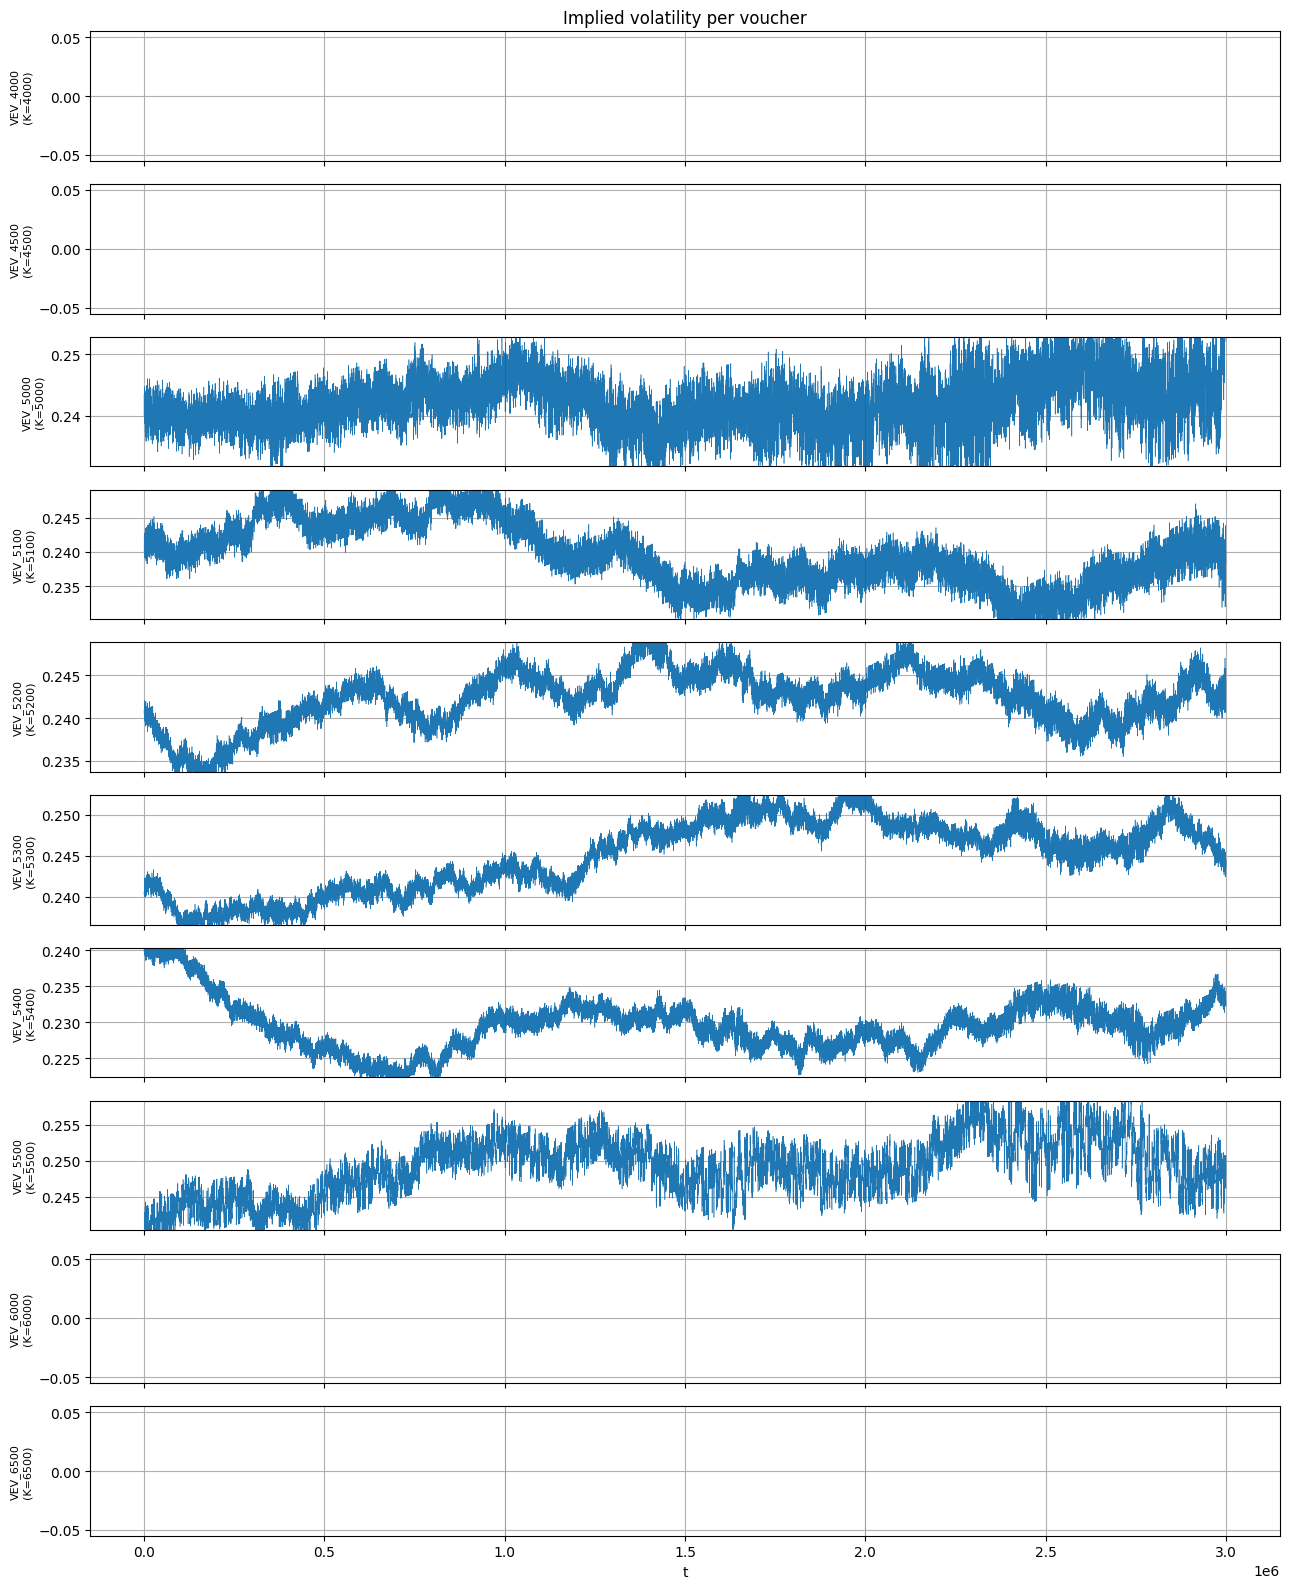

In [10]:
fig, axes = plt.subplots(len(VOUCHERS), 1, figsize=(13, 1.6*len(VOUCHERS)), sharex=True)
for ax, v in zip(axes, VOUCHERS):
    s = wide[f'iv_{v}']
    ax.plot(wide['t'], s, lw=0.4)
    ax.set_ylabel(f'{v}\n(K={STRIKES[v]})', fontsize=8)
    if s.notna().sum() > 0:
        ax.set_ylim(np.nanpercentile(s, 1), np.nanpercentile(s, 99))
    for d in [1_000_000, 2_000_000]:
        ax.axvline(d, color='k', alpha=0.15, lw=0.5)
axes[0].set_title('Implied volatility per voucher')
axes[-1].set_xlabel('t')
plt.tight_layout(); plt.show()

## 8. Volatility smile fit

Moneyness `m = ln(K/S) / sqrt(TTE)`. Fit a global parabola `iv ≈ a*m² + b*m + c`, plus per-day fits to check stationarity.

In [11]:
long_rows = []
for v in VOUCHERS:
    K = STRIKES[v]
    sub = wide[['day','t','tte', UNDERLYING, f'iv_{v}']].copy()
    sub = sub.rename(columns={UNDERLYING: 'S', f'iv_{v}': 'iv'}).dropna(subset=['iv','S'])
    sub['voucher'] = v
    sub['K'] = K
    sub['m'] = np.log(sub['K'] / sub['S']) / np.sqrt(sub['tte'])
    long_rows.append(sub[['day','t','tte','voucher','K','S','iv','m']])
long = pd.concat(long_rows, ignore_index=True)
print('total IV observations:', len(long))
print(long.groupby('voucher').size())

total IV observations: 179886
voucher
VEV_5000    29886
VEV_5100    30000
VEV_5200    30000
VEV_5300    30000
VEV_5400    30000
VEV_5500    30000
dtype: int64


In [12]:
coeffs_global = np.polyfit(long['m'], long['iv'], deg=2)
fit_global = np.poly1d(coeffs_global)
print(f'global parabola coeffs (a, b, c): {coeffs_global}')
print(f'  iv_hat(m) = {coeffs_global[0]:.6f}*m^2 + {coeffs_global[1]:.6f}*m + {coeffs_global[2]:.6f}')

per_day_coeffs = {}
for d in sorted(long['day'].unique()):
    sub = long[long['day'] == d]
    per_day_coeffs[d] = np.polyfit(sub['m'], sub['iv'], deg=2)
for d, c in per_day_coeffs.items():
    print(f'  day {d}: a={c[0]:+.5f}  b={c[1]:+.5f}  c={c[2]:+.5f}')

global parabola coeffs (a, b, c): [0.03037029 0.00224891 0.23941452]
  iv_hat(m) = 0.030370*m^2 + 0.002249*m + 0.239415
  day 0: a=+0.04588  b=-0.00428  c=+0.23784
  day 1: a=+0.01129  b=+0.00440  c=+0.24089
  day 2: a=+0.03442  b=+0.00531  c=+0.23961


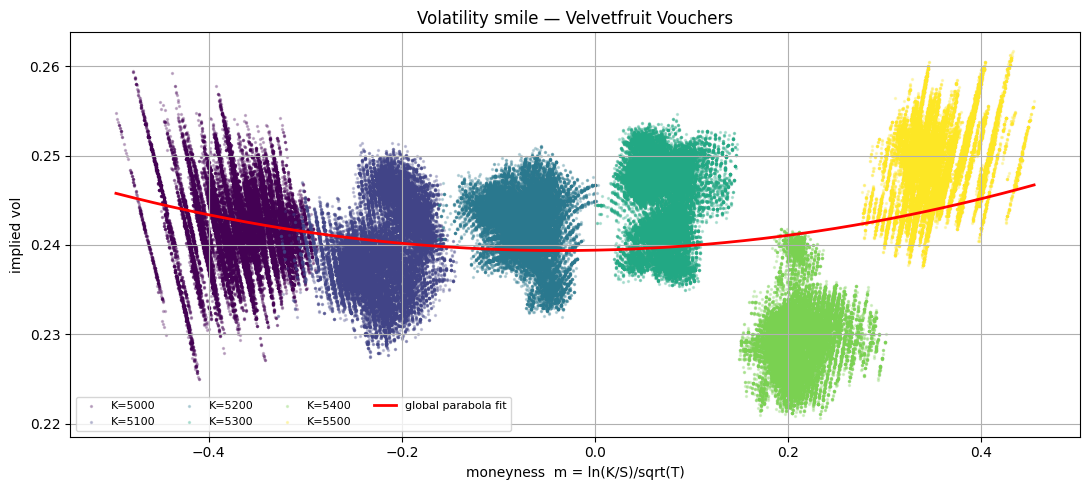

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
cmap = plt.cm.viridis
ks = sorted(long['K'].unique())
for i, K in enumerate(ks):
    sub = long[long['K'] == K]
    ax.scatter(sub['m'], sub['iv'], s=2, alpha=0.25, color=cmap(i/max(1,len(ks)-1)), label=f'K={K}')
m_grid = np.linspace(long['m'].min(), long['m'].max(), 200)
ax.plot(m_grid, fit_global(m_grid), 'r-', lw=2, label='global parabola fit')
ax.set_xlabel('moneyness  m = ln(K/S)/sqrt(T)'); ax.set_ylabel('implied vol')
ax.set_title('Volatility smile — Velvetfruit Vouchers')
ax.legend(ncol=4, fontsize=8)
plt.tight_layout(); plt.show()

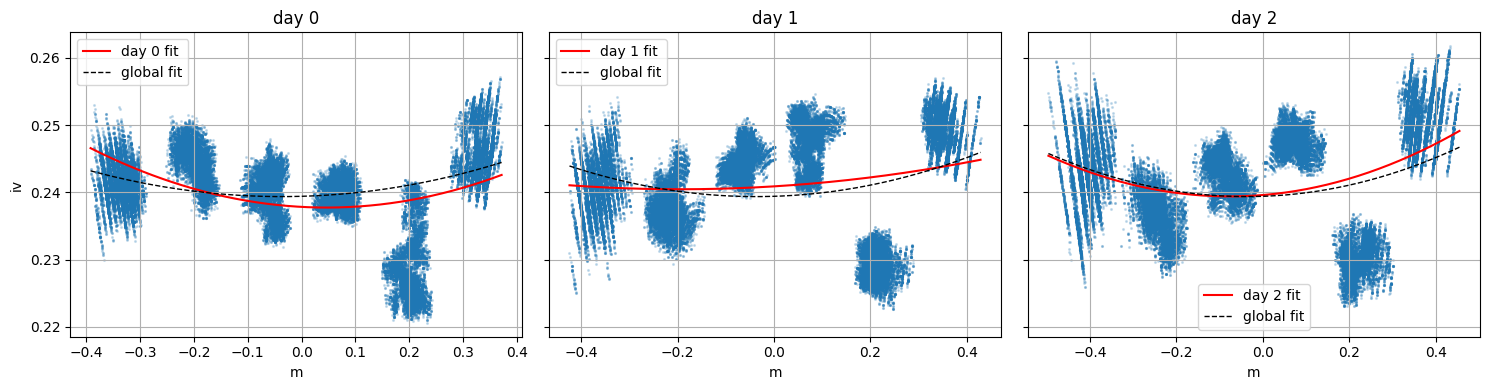

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for d, ax in zip(sorted(long['day'].unique()), axes):
    sub = long[long['day'] == d]
    ax.scatter(sub['m'], sub['iv'], s=1.5, alpha=0.2, c='tab:blue')
    g = np.linspace(sub['m'].min(), sub['m'].max(), 200)
    ax.plot(g, np.poly1d(per_day_coeffs[d])(g), 'r-', lw=1.5, label=f'day {d} fit')
    ax.plot(g, fit_global(g), 'k--', lw=1, label='global fit')
    ax.set_title(f'day {d}'); ax.legend()
    ax.set_xlabel('m')
axes[0].set_ylabel('iv')
plt.tight_layout(); plt.show()

## 9. IV deviations over time

`Δσ = σ_observed − σ̂(m)` using the global parabola. Mean-reverting ⇒ scalpable.

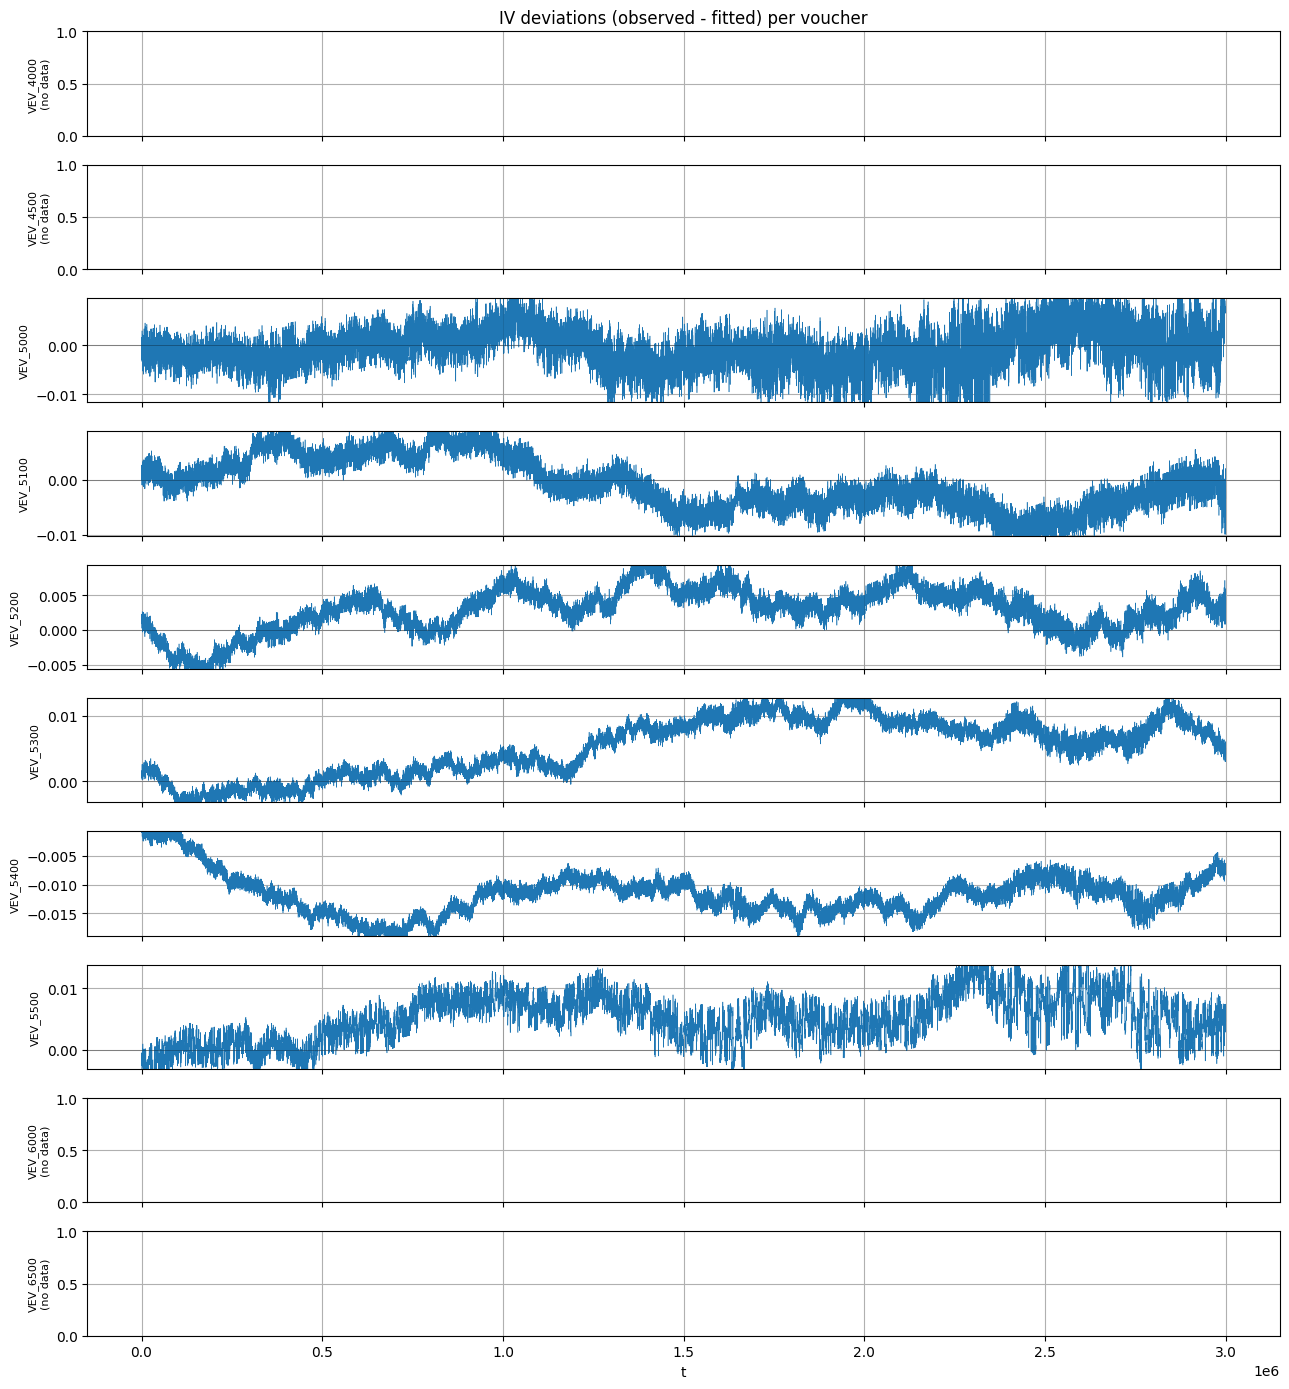

In [15]:
long['iv_hat'] = fit_global(long['m'])
long['iv_dev'] = long['iv'] - long['iv_hat']

iv_dev_w = long.pivot_table(index='t', columns='voucher', values='iv_dev').reindex(columns=VOUCHERS)

fig, axes = plt.subplots(len(VOUCHERS), 1, figsize=(13, 1.4*len(VOUCHERS)), sharex=True)
for ax, v in zip(axes, VOUCHERS):
    s = iv_dev_w[v].dropna()
    if len(s) == 0:
        ax.set_ylabel(f'{v}\n(no data)', fontsize=8); continue
    ax.plot(s.index, s.values, lw=0.4)
    ax.axhline(0, color='k', lw=0.4, alpha=0.5)
    ax.set_ylabel(f'{v}', fontsize=8)
    ax.set_ylim(np.nanpercentile(s, 1), np.nanpercentile(s, 99))
    for d in [1_000_000, 2_000_000]:
        ax.axvline(d, color='k', alpha=0.15, lw=0.5)
axes[0].set_title('IV deviations (observed - fitted) per voucher')
axes[-1].set_xlabel('t')
plt.tight_layout(); plt.show()

## 10. Price-space deviations

Push `σ̂(m)` through BS to get a theoretical price; compare to the mid. Deviation is in XIRECS — directly comparable to spread thresholds.

In [16]:
def theo_price(S, K, T, sigma):
    if not (np.isfinite(S) and np.isfinite(sigma)) or sigma <= 0:
        return np.nan
    return bs_call(S, K, T, sigma)[0]

long['theo'] = [theo_price(S, K, T, iv) for S, K, T, iv in zip(long['S'], long['K'], long['tte'], long['iv_hat'])]

actual = []
for v in VOUCHERS:
    sub = wide[['t', v]].rename(columns={v: 'mid'}).copy()
    sub['voucher'] = v
    actual.append(sub)
actual_df = pd.concat(actual, ignore_index=True)
long = long.merge(actual_df, on=['t','voucher'], how='left')
long['price_dev'] = long['mid'] - long['theo']

long['delta'] = [bs_call(S, K, T, iv)[1] if (np.isfinite(iv) and iv > 0) else np.nan
                 for S, K, T, iv in zip(long['S'], long['K'], long['tte'], long['iv_hat'])]
long['vega']  = [bs_vega(S, K, T, iv) if (np.isfinite(iv) and iv > 0) else np.nan
                 for S, K, T, iv in zip(long['S'], long['K'], long['tte'], long['iv_hat'])]

long.head()

,day,t,tte,voucher,K,S,iv,m,iv_hat,iv_dev,theo,mid,price_dev,delta,vega
0,0,0,0.021918,VEV_5000,5000,5250.0,0.243525,-0.329559,0.241972,0.001553,257.313050,257.5,0.186950,0.916189,119.674405
1,0,100,0.021918,VEV_5000,5000,5251.0,0.240026,-0.330848,0.241995,-0.001969,258.232195,258.0,-0.232195,0.916986,118.839525
2,0,200,0.021917,VEV_5000,5000,5250.0,0.243528,-0.329564,0.241972,0.001556,257.312697,257.5,0.187303,0.916192,119.670202
3,0,300,0.021917,VEV_5000,5000,5250.0,0.243529,-0.329566,0.241972,0.001557,257.312520,257.5,0.187480,0.916193,119.668100
4,0,400,0.021917,VEV_5000,5000,5250.0,0.243531,-0.329568,0.241972,0.001559,257.312344,257.5,0.187656,0.916194,119.665999


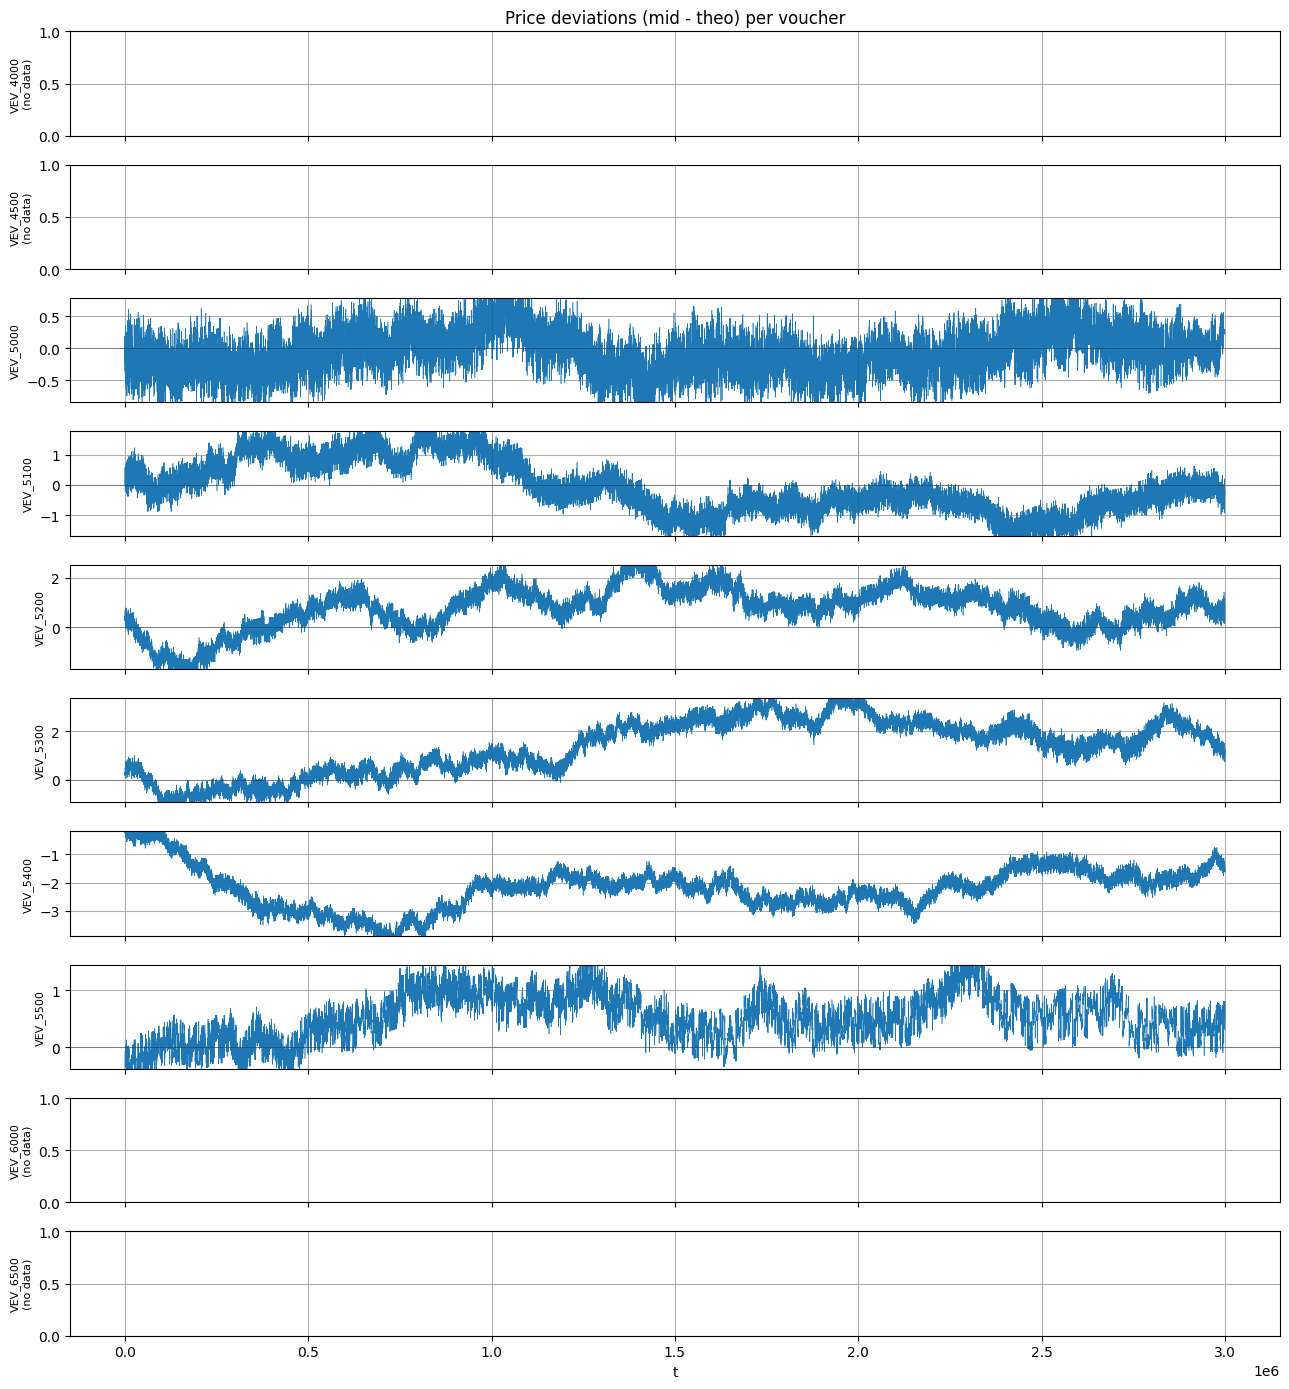

In [17]:
price_dev_w = long.pivot_table(index='t', columns='voucher', values='price_dev').reindex(columns=VOUCHERS)

fig, axes = plt.subplots(len(VOUCHERS), 1, figsize=(13, 1.4*len(VOUCHERS)), sharex=True)
for ax, v in zip(axes, VOUCHERS):
    s = price_dev_w[v].dropna()
    if len(s) == 0:
        ax.set_ylabel(f'{v}\n(no data)', fontsize=8); continue
    ax.plot(s.index, s.values, lw=0.4)
    ax.axhline(0, color='k', lw=0.4, alpha=0.5)
    ax.set_ylabel(f'{v}', fontsize=8)
    ax.set_ylim(np.nanpercentile(s, 1), np.nanpercentile(s, 99))
    for d in [1_000_000, 2_000_000]:
        ax.axvline(d, color='k', alpha=0.15, lw=0.5)
axes[0].set_title('Price deviations (mid - theo) per voucher')
axes[-1].set_xlabel('t')
plt.tight_layout(); plt.show()

## 11. Autocorrelation — is the deviation mean-reverting?

1-lag AC on the deviation itself, on its first difference, plus multi-lag ACF.

In [18]:
rows = []
for v in VOUCHERS:
    s = price_dev_w[v].dropna()
    if len(s) < 100:
        rows.append({'voucher': v, 'K': STRIKES[v], 'n': len(s),
                     'ac1_dev': np.nan, 'ac1_diff': np.nan, 'std_dev': np.nan})
        continue
    rows.append({
        'voucher': v, 'K': STRIKES[v], 'n': len(s),
        'ac1_dev':  s.autocorr(lag=1),
        'ac1_diff': s.diff().autocorr(lag=1),
        'std_dev':  s.std(),
    })
ac = pd.DataFrame(rows)
ac

,voucher,K,n,ac1_dev,ac1_diff,std_dev
0,VEV_4000,4000,0,NaN,NaN,NaN
1,VEV_4500,4500,0,NaN,NaN,NaN
2,VEV_5000,5000,29886,0.433635,-0.493732,0.357898
3,VEV_5100,5100,30000,0.911422,-0.487420,0.869984
4,VEV_5200,5200,30000,0.936331,-0.493158,0.874771
5,VEV_5300,5300,30000,0.971926,-0.480755,1.126530
6,VEV_5400,5400,30000,0.963328,-0.452829,0.763707
7,VEV_5500,5500,30000,0.927982,-0.330327,0.414351
8,VEV_6000,6000,0,NaN,NaN,NaN
9,VEV_6500,6500,0,NaN,NaN,NaN


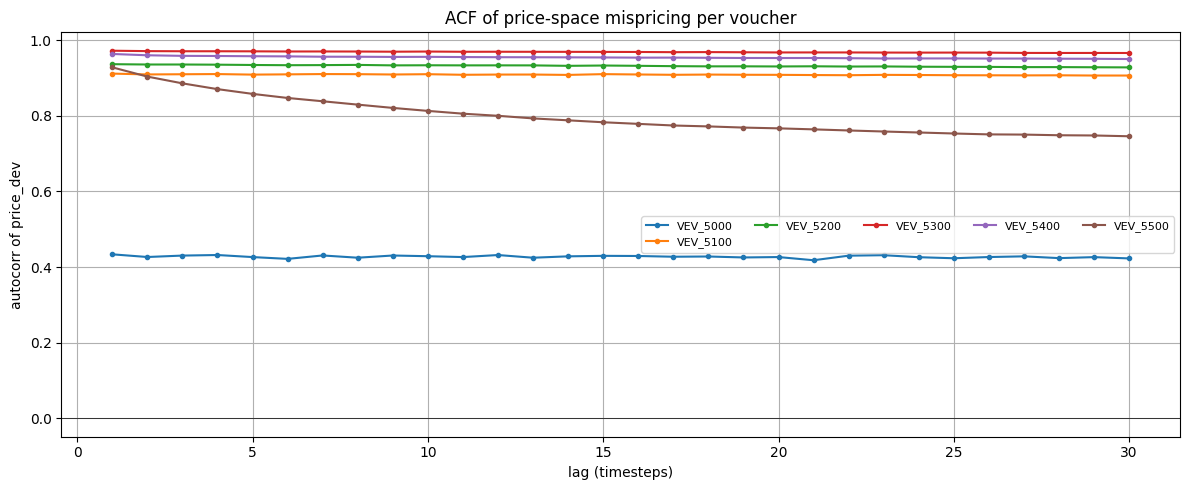

In [19]:
MAX_LAG = 30
fig, ax = plt.subplots(figsize=(12, 5))
for v in VOUCHERS:
    s = price_dev_w[v].dropna()
    if len(s) < MAX_LAG + 10: continue
    acs = [s.autocorr(lag=k) for k in range(1, MAX_LAG+1)]
    ax.plot(range(1, MAX_LAG+1), acs, marker='.', label=v)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('lag (timesteps)'); ax.set_ylabel('autocorr of price_dev')
ax.set_title('ACF of price-space mispricing per voucher')
ax.legend(ncol=5, fontsize=8)
plt.tight_layout(); plt.show()

## 12. Underlying autocorrelation — mean reversion side-bet?

ACF of `VELVETFRUIT_EXTRACT` returns vs a shuffled-null 95% band. If the red line drops below the band at lag 1+, mean reversion is real.

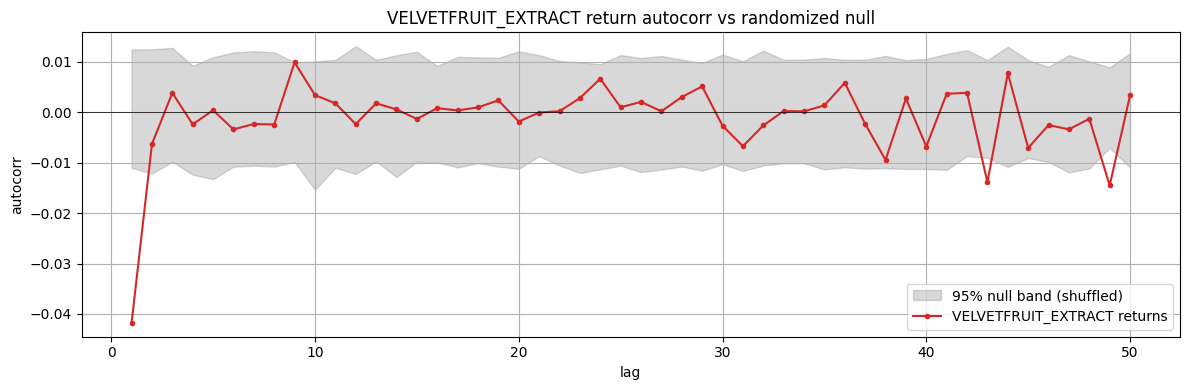

In [20]:
u = wide[['t', UNDERLYING]].dropna().rename(columns={UNDERLYING: 'S'})
u['ret'] = u['S'].diff()

MAX_LAG_U = 50
real_acs = [u['ret'].autocorr(lag=k) for k in range(1, MAX_LAG_U+1)]

rng = np.random.default_rng(0)
N_SIM = 200
ret_arr = u['ret'].dropna().to_numpy()
sim = np.zeros((N_SIM, MAX_LAG_U))
for i in range(N_SIM):
    perm = rng.permutation(ret_arr)
    s = pd.Series(perm)
    sim[i] = [s.autocorr(lag=k) for k in range(1, MAX_LAG_U+1)]
lo = np.nanpercentile(sim, 2.5, axis=0)
hi = np.nanpercentile(sim, 97.5, axis=0)

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(range(1, MAX_LAG_U+1), lo, hi, color='gray', alpha=0.3, label='95% null band (shuffled)')
ax.plot(range(1, MAX_LAG_U+1), real_acs, marker='.', color='tab:red', label=f'{UNDERLYING} returns')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('lag'); ax.set_ylabel('autocorr')
ax.set_title(f'{UNDERLYING} return autocorr vs randomized null')
ax.legend()
plt.tight_layout(); plt.show()

## 13. Strike viability — which vouchers are worth scalping?

Combine liquidity (n), payoff per fire (`std_dev`), signal quality (`-ac1_diff`), and vega.

In [21]:
vega_mean = long.groupby('voucher')['vega'].mean().rename('mean_vega')
delta_mean = long.groupby('voucher')['delta'].mean().rename('mean_delta')
viable = ac.merge(vega_mean, left_on='voucher', right_index=True, how='left')
viable = viable.merge(delta_mean, left_on='voucher', right_index=True, how='left')
viable['score'] = (viable['n'] / viable['n'].max()) * viable['std_dev'].fillna(0) * (-viable['ac1_diff'].fillna(0)).clip(lower=0)
viable.sort_values('score', ascending=False)

,voucher,K,n,ac1_dev,ac1_diff,std_dev,mean_vega,mean_delta,score
5,VEV_5300,5300,30000,0.971926,-0.480755,1.126530,267.128308,0.390144,0.541585
4,VEV_5200,5200,30000,0.936331,-0.493158,0.874771,264.006346,0.624716,0.431400
3,VEV_5100,5100,30000,0.911422,-0.487420,0.869984,182.072537,0.821384,0.424048
6,VEV_5400,5400,30000,0.963328,-0.452829,0.763707,192.478563,0.195321,0.345829
2,VEV_5000,5000,29886,0.433635,-0.493732,0.357898,88.447319,0.935287,0.176034
7,VEV_5500,5500,30000,0.927982,-0.330327,0.414351,103.146465,0.079119,0.136871
0,VEV_4000,4000,0,NaN,NaN,NaN,NaN,NaN,-0.000000
1,VEV_4500,4500,0,NaN,NaN,NaN,NaN,NaN,-0.000000
8,VEV_6000,6000,0,NaN,NaN,NaN,NaN,NaN,-0.000000
9,VEV_6500,6500,0,NaN,NaN,NaN,NaN,NaN,-0.000000


Reading the table:
- **High score**: liquid + meaningful price-dev std + negatively autocorrelated → primary scalping universe.
- **Score ≈ 0**: either no IV inversion (dead books) or no mean reversion.
- Frankfurt last year scalped K ≥ 9750 (i.e. dropped only the deepest-ITM 9500) and used 9500 for mean reversion.

## 14. Threshold sizing — where to set THR_OPEN / THR_CLOSE?

Histograms of `price_dev` per viable voucher. Frankfurt used `THR_OPEN=0.5, THR_CLOSE=0` (price units).

viable scalping universe: ['VEV_5300', 'VEV_5200', 'VEV_5100', 'VEV_5400', 'VEV_5000', 'VEV_5500']


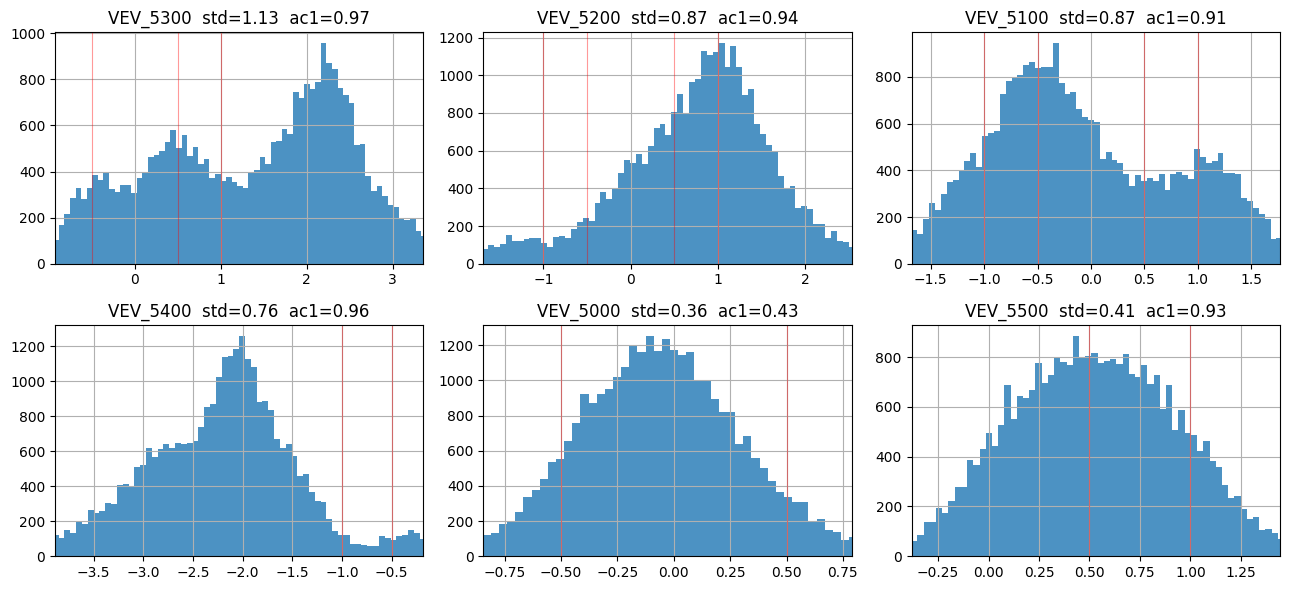

In [22]:
viable_vouchers = viable[viable['score'] > 0].sort_values('score', ascending=False)['voucher'].tolist()
print('viable scalping universe:', viable_vouchers)

n = len(viable_vouchers)
if n > 0:
    cols = 3
    rows_ = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows_, cols, figsize=(13, 3*rows_))
    axes = np.atleast_1d(axes).flatten()
    for ax, v in zip(axes, viable_vouchers):
        s = price_dev_w[v].dropna()
        ax.hist(s, bins=80, alpha=0.8)
        for thr in [-1.0, -0.5, 0.5, 1.0]:
            ax.axvline(thr, color='r', alpha=0.4, lw=0.8)
        ax.set_title(f'{v}  std={s.std():.2f}  ac1={s.autocorr(1):.2f}')
        ax.set_xlim(np.nanpercentile(s, 1), np.nanpercentile(s, 99))
    for ax in axes[n:]: ax.axis('off')
    plt.tight_layout(); plt.show()

## 15. HYDROGEL_PACK — quick sanity (independent product)

Spread, mid range, return autocorr. Strategy choice for HYDROGEL is separate from options.

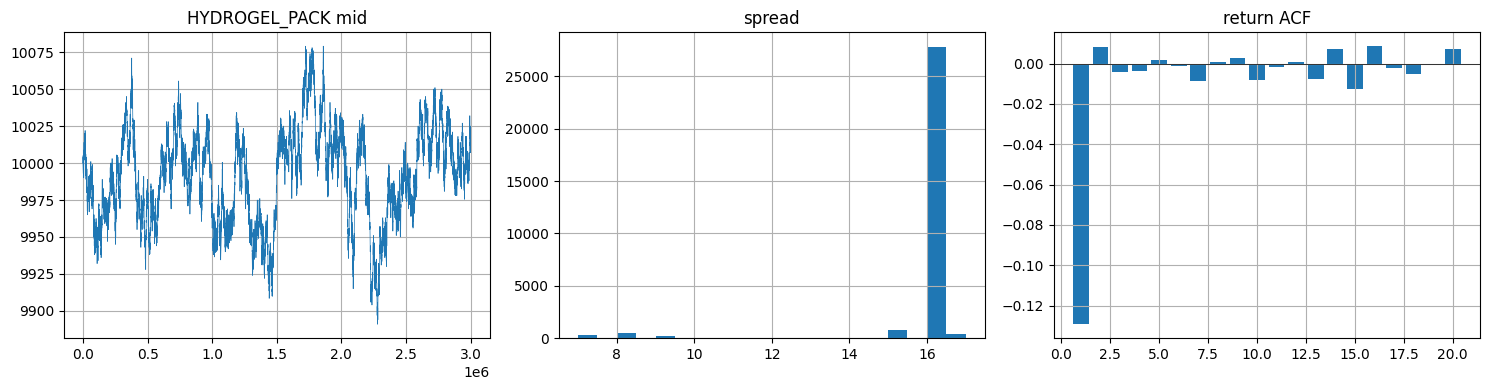

mid:  min=9891.0  max=10079.0  mean=9990.8  std=31.94
spread: mean=15.72  median=16.00
ret std: 2.17   ac1: -0.129


In [23]:
h = prices[prices['product'] == INDEPENDENT].sort_values('t').copy()
h['spread'] = h['ask_price_1'] - h['bid_price_1']
h['ret'] = h['mid_price'].diff()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(h['t'], h['mid_price'], lw=0.5); axes[0].set_title(f'{INDEPENDENT} mid')
axes[1].hist(h['spread'].dropna(), bins=20); axes[1].set_title('spread')
axes[2].bar(range(1, 21), [h['ret'].autocorr(lag=k) for k in range(1, 21)])
axes[2].set_title('return ACF'); axes[2].axhline(0, color='k', lw=0.5)
plt.tight_layout(); plt.show()

print(f"mid:  min={h['mid_price'].min():.1f}  max={h['mid_price'].max():.1f}  mean={h['mid_price'].mean():.1f}  std={h['mid_price'].std():.2f}")
print(f"spread: mean={h['spread'].mean():.2f}  median={h['spread'].median():.2f}")
print(f"ret std: {h['ret'].std():.2f}   ac1: {h['ret'].autocorr(1):.3f}")

## What to look for in the outputs

- **Smile shape** (cell 8): clean U with `a > 0` is the textbook smile. If per-day fits drift noticeably, we need an online-fitted smile in the live trader, not hardcoded coeffs.
- **IV deviation series** (cell 9): oscillating around 0 with no trend ⇒ smile is a good fair-value model.
- **ACF table** (cell 11): negative `ac1_diff` for ≥3-4 strikes is the green light for IV scalping. Frankfurt got strong negative AC across most strikes.
- **Underlying ACF** (cell 12): red line below the gray null band at lag 1 ⇒ mean reversion on the underlying is real.
- **Viability table** (cell 13): defines the scalping universe for the live trader.
- **Histograms** (cell 14): pick `THR_OPEN` so tails fire often (top ~20% of |dev|) but well outside the bulk.